In [1]:
"""
THIS SCRIPT IS not actually helpful.
it was made with a misunderstanding of the cosine plot of area vs angle.
after adjusting this script to use physically accurate math it is no longer helpful in the way it was designed for.
keep that in mind while reading
"""


!pip install pandas

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from numpy.polynomial import Polynomial

"""
explainer

This is a python script designed to find the slowest possible cycle rate the solar firmware could theoretically run at.
This is useful because we want the firmware to be running as little as possible to maximize the ammount of time in sleep mode.
This presents a challenge in that when the satellite is spinning (as satellites tend to do) the IP curve we are tracking will also be changing.
The danger is when the solar intensity is reducing and we are somewhere near the peak of the IP curve.
There is not much room between the peak of the IP curve and the cliff. 
 - and since the whole thing is shrinking with solar intensity it creates a situation where if we sleep for too long the curve will move out from underneath us, and cause a brown out. :(


initially I thought this would occur when when the intensity is changing the fastest, this is strategy A.
it finds the fastest the MPP will move in current/time and divides it with a distance parameter than the user sets, which is meant to be an estimation of how far the MPP is from the cliff.

strategy B should be a lot more helpful.
I realized that the distance between the MPP and cliff should scale linearly with the entire curve.
this means that we should be able to find a tuning constant that relates the position of the MPP to the cliff.

this strategy is looking for the sweet spot during the descent, between when the MPP is moving the fastest, and when the distance between MPP and cliff is really tiny near min intensity.

it finds the distance of MPP to cliff distance (the fall) at some intensity, and divides it by the rate of change of current at that point, to find the timeframe we need to react in.


"""


Defaulting to user installation because normal site-packages is not writeable


'\nexplainer\n\nThis is a python script designed to find the slowest possible cycle rate the solar firmware could theoretically run at.\nThis is useful because we want the firmware to be running as little as possible to maximize the ammount of time in sleep mode.\nThis presents a challenge in that when the satellite is spinning (as satellites tend to do) the IP curve we are tracking will also be changing.\nThe danger is when the solar intensity is reducing and we are somewhere near the peak of the IP curve.\nThere is not much room between the peak of the IP curve and the cliff. \n - and since the whole thing is shrinking with solar intensity it creates a situation where if we sleep for too long the curve will move out from underneath us, and cause a brown out. :(\n\n\ninitially I thought this would occur when when the intensity is changing the fastest, this is strategy A.\nit finds the fastest the MPP will move in current/time and divides it with a distance parameter than the user sets

In [2]:


#import data from ./data/full-spectrum/
#10 files, each has one line containing data describing the maximum power point of a sweep.
#the intensity of that sweep is the filename from 0.1 to 1.0

with open('data/full-spectrum/0.1') as f:
    one = list(map(int, f.readlines()[0].split()))

with open('data/full-spectrum/0.2') as f:
    two = list(map(int, f.readlines()[0].split()))

with open('data/full-spectrum/0.3') as f:
    three = list(map(int, f.readlines()[0].split()))

with open('data/full-spectrum/0.4') as f:
    four = list(map(int, f.readlines()[0].split()))

with open('data/full-spectrum/0.5') as f:
    five = list(map(int, f.readlines()[0].split()))

with open('data/full-spectrum/0.6') as f:
    six = list(map(int, f.readlines()[0].split()))

with open('data/full-spectrum/0.7') as f:
    seven = list(map(int, f.readlines()[0].split()))

with open('data/full-spectrum/0.8') as f:
    eight = list(map(int, f.readlines()[0].split()))

with open('data/full-spectrum/0.9') as f:
    nine = list(map(int, f.readlines()[0].split()))

with open('data/full-spectrum/1.0') as f:
    ten = list(map(int, f.readlines()[0].split()))

#load those values into arrays for easier access
MPPp = [one[2], two[2], three[2], four[2], five[2], six[2], seven[2], eight[2], nine[2], ten[2]]
MPPc = [one[0], two[0], three[0], four[0], five[0], six[0], seven[0], eight[0], nine[0], ten[0]]
MPPpercent = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]


print (MPPp)
print (MPPc)


[434, 697, 984, 1224, 1481, 1732, 1889, 2177, 2383, 2411]
[89060, 143080, 201480, 250560, 301820, 350980, 374020, 446160, 482500, 482520]


[ 60217.33333333 458183.03030303]


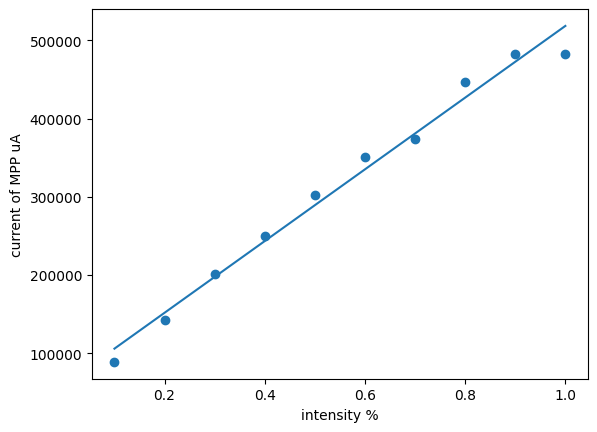

In [3]:

#graph the relationship of the intensity of light with Impp (current of the maximum power point)

plt.xlabel("intensity %")
plt.ylabel("current of MPP uA")
plt.scatter(MPPpercent, MPPc)

#find the linear fit line of the data 
poly = Polynomial.fit(MPPpercent, MPPc, 1)
print (poly.convert().coef) #print the coefficients of the line [yint slope]
plt.plot(MPPpercent, poly(MPPpercent))

#lucky this is a linear relationship

10.0
0.31400424672597854
-0.3141592653589793
0.31400424672597854


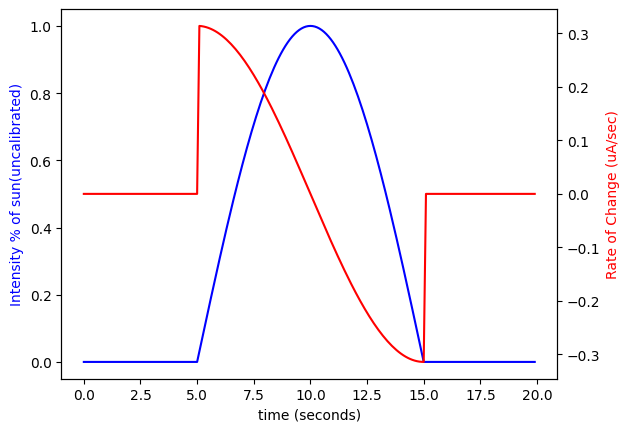

In [4]:
#20 seconds for 1 period. doesn't matter for calculations, just makes the graphs look better
time = np.arange(0, 20, 0.1)

rpm = 3 #choose the rpm we expect the satellite to be rotating at along it's z axis (bbq style)

facing_time = 60/(2*rpm) #caclulate how long a panel will be exposed to the sun for.
                          #note the factor of 2 since more than one panel can be exposed at once
print(facing_time)

#adjust sinusoid parameters
amplitude = 1
freq = np.pi/(facing_time)
phase = np.pi
offset = 0

def intensity_wave(time):
    val = amplitude*np.cos(time*freq+phase)+offset
    if val < 0:
        return 0
    return amplitude*np.cos(time*freq+phase)+offset

#first derivative of intensity wave
def deriv_wave(time):
    val = amplitude*np.cos(time*freq+phase)+offset
    if val < 0:
        return 0
    return -amplitude*freq*np.sin(time*freq+phase)


intensity = [0] * len(time)
deriv = [0] * len(time)


for idx in range(len(time)):
    intensity[idx] = intensity_wave(time[idx])

for idx in range(len(time)):
    deriv[idx] = deriv_wave(time[idx])


#see what the waves look like
fig, ax1 = plt.subplots()
plt.xlabel("time (seconds)")
ax1.set_ylabel("Intensity % of sun(uncalibrated)", color='b')
ax2 = plt.twinx()
ax2.set_ylabel("Rate of Change (uA/sec)", color='r')
ax1.plot(time, intensity, 'b')
ax2.plot(time, deriv, 'r')


print (max(deriv))
print (min(deriv))
max_speed = max(deriv)
print (max_speed)
#in % intensity per second


#translate from intensity to current using the polynomial we found earlier
def int_to_current(intensity):
#    return 115839 + 76197*(-2.333+4.444*intensity)
    return poly(intensity)

#same as above but ensure it's all positive, helpful for making sure the derivative isn't offset
def int_to_current_no_offset(intensity):
    rtn = poly(intensity) - poly.convert().coef[0]
    # if (rtn < 0):
    #     rtn *= -1
    return rtn

In [5]:
#Strategy A
#manual distance setting
#assume halfway down the descent is where the problem is

#change in current/sec at peak speed
delta = int_to_current(max_speed) - int_to_current(0)

print ("detla is", delta) #in uA/sec

dist_mA = 5 # distance from peak to cliff in mA
             # probably 1 to 5 mA

# (mA) / (uA/sec) evals to ks but we want ms so a factor of 1,000,000 is needed
print("method A", dist_mA*1000000/(delta), "ms")



detla is 143871.41729292928
method A 34.75325463583746 ms


(-20.0, 100.0)

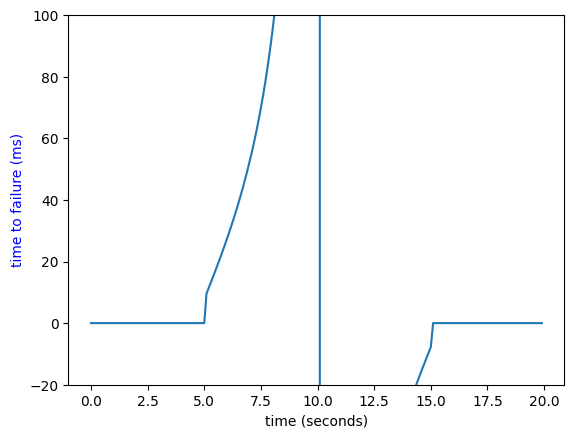

In [6]:
#Strategy B
#



#initialize a 2 by len(time) array
ttf_arr = [[0]*len(time) for i in range(2)]

fall_ratio = 1.01851 - 1
#fall_ratio = 1.04 - 1

for idx in range(len(intensity)):
    mCurrent = int_to_current(intensity[idx]) # uA
    mRate = int_to_current_no_offset(deriv[idx]) # uA/sec
    # mCurrent = 5
   # print(idx, mCurrent)
    ttf_arr[0][idx] = mCurrent
    # distance over speed
    if (mRate != 0): 
                          # (uA * scalar * 1000) / (- uA / sec) = mili seconds
        ttf_arr[1][idx] = (mCurrent * fall_ratio * 1000) / (mRate) #the rate is negitive because.... Idk why but flipping it makes the graph make more sense
    else:
        ttf_arr[1][idx] = 0

plt.plot(time, ttf_arr[1])
plt.xlabel("time (seconds)")
plt.ylabel("time to failure (ms)", color='b')
plt.ylim(-20, 100)


(-200.0, 200.0)

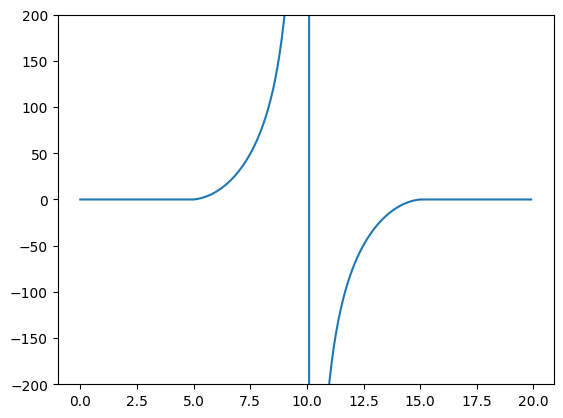

In [7]:
#print(ttf_arr[1])
wuh = np.multiply(ttf_arr[1], intensity)
# wuh = [0] * len(time)
# for idx in time:
    # wuh[idx] = ttf_arr[1][idx] * intensity[idx]

plt.plot(time, wuh)
plt.ylim(-200, 200)
